In [49]:
# Importing Libraries
import torch
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import GATConv,SAGEConv
from torch_geometric.utils import to_networkx,subgraph
from torch_geometric.loader import NeighborLoader
from torch.nn import Linear
import torch.nn.functional as F
import networkx as nx
import pandas as pd
import numpy as np
import random
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
print("All libraries imported!")

All libraries imported!


In [50]:
# Loading the Graph:
graph=torch.load('/Users/rageshwer/Goal ML/Projects/AML - GNN/data/graphs/elliptic_graph_processed.pt',weights_only=False)
print("Graph loaded")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Graph loaded


In [51]:
# Defining the Graph Network:
class hybridGNN(torch.nn.Module):

    def __init__(self,in_channels,hidden_channels,out_channel,heads=4,dropout=0.2):
        super().__init__()
        self.sage=SAGEConv(in_channels,hidden_channels)
        self.gat=GATConv(hidden_channels,hidden_channels,heads=heads)

        self.lin=Linear(hidden_channels*heads,out_channel)

        self.dropout=torch.nn.Dropout(p=dropout)

    def forward(self,x,edge_index):
        x=self.sage(x,edge_index)
        x=F.relu(x)
        x=self.dropout(x)

        x=self.gat(x,edge_index)
        x=F.elu(x)
        x=self.dropout(x)

        return self.lin(x)

In [52]:
# Defining the Focal Point Loss class:
class FocalLoss(torch.nn.Module):
    def __init__(self,alpha=1,gamma=2,reduction='mean'):
        super().__init__()
        self.alpha=alpha
        self.gamma=gamma
        self.reduction=reduction

    def forward(self,inputs,targets):
        inputs=inputs.view(-1)
        targets=targets.view(-1)

        BCE_loss=F.binary_cross_entropy_with_logits(inputs,targets,reduction='none')    # we need probs for each [a tensor], not the average loss
        probs=torch.exp(-BCE_loss)

        focal_loss_logits= self.alpha * ((1-probs)**self.gamma) * BCE_loss              # the BCE loss = -log(p)

        if self.reduction=='mean':
            return focal_loss_logits.mean()
        elif self.reduction=='sum':
            return focal_loss_logits.sum()
        else:
            return focal_loss_logits

In [53]:
# The training parameters:
model=hybridGNN(in_channels=165,hidden_channels=64,out_channel=1)
criterion=FocalLoss(alpha=1,gamma=3,reduction='mean')
optimizer=torch.optim.Adam(model.parameters(),lr=0.005)
scheduler=torch.optim.lr_scheduler.ExponentialLR(optimizer=optimizer,gamma=0.95)

batch_size=1024
num_neighbors=[30,10]
EPOCHS=30

In [54]:
# The training:
print("Training started in chronological order.")
for epoch in range(1,EPOCHS+1):

    model.train()
    epoch_loss=0.0
    total_nodes_processed = 0

    for t in range(1,35):
        # Selects the indices of nodes in current timestep and train masked as a tensor
        timestep_mask = graph.timestep==t
        current_target_nodes = torch.where(timestep_mask & graph.train_mask)[0]
        if len(current_target_nodes)==0: continue

        loader=NeighborLoader(graph,num_neighbors=num_neighbors,
                              batch_size=batch_size,input_nodes=current_target_nodes,
                              shuffle=True)
        
        for batch in loader:
            optimizer.zero_grad()

            logits=model(batch.x,batch.edge_index)
            
            # Calculate the loss for only the target nodes and not the neighbours
            num_targets=batch.batch_size
            batch_loss=criterion(logits[:num_targets],batch.y[:num_targets].float())               

            batch_loss.backward()
            optimizer.step()

            epoch_loss +=batch_loss.item() * num_targets
            total_nodes_processed += num_targets

    avg_epoch_loss= epoch_loss/total_nodes_processed
    print(f"Epoch : {epoch} | Loss : {avg_epoch_loss:.4f}")
    scheduler.step()

print("==============================================================================================")
print("Training complete.")

Training started in chronological order.
Epoch : 1 | Loss : 0.0577
Epoch : 2 | Loss : 0.0333
Epoch : 3 | Loss : 0.0264
Epoch : 4 | Loss : 0.0247
Epoch : 5 | Loss : 0.0211
Epoch : 6 | Loss : 0.0183
Epoch : 7 | Loss : 0.0149
Epoch : 8 | Loss : 0.0137
Epoch : 9 | Loss : 0.0127
Epoch : 10 | Loss : 0.0122
Epoch : 11 | Loss : 0.0119
Epoch : 12 | Loss : 0.0115
Epoch : 13 | Loss : 0.0098
Epoch : 14 | Loss : 0.0094
Epoch : 15 | Loss : 0.0087
Epoch : 16 | Loss : 0.0085
Epoch : 17 | Loss : 0.0080
Epoch : 18 | Loss : 0.0077
Epoch : 19 | Loss : 0.0076
Epoch : 20 | Loss : 0.0072
Epoch : 21 | Loss : 0.0068
Epoch : 22 | Loss : 0.0066
Epoch : 23 | Loss : 0.0065
Epoch : 24 | Loss : 0.0064
Epoch : 25 | Loss : 0.0062
Epoch : 26 | Loss : 0.0059
Epoch : 27 | Loss : 0.0058
Epoch : 28 | Loss : 0.0056
Epoch : 29 | Loss : 0.0056
Epoch : 30 | Loss : 0.0054
Training complete.


In [55]:
# Evaluation of model:
model.eval()
all_probs=[]
all_targets=[]
print('Evaluation starting in chronological order...')
with torch.no_grad():
    for t in range(35,50):
        time_mask = graph.timestep==t
        current_target_nodes= torch.where(time_mask & graph.test_mask)[0]
        if len(current_target_nodes)==0: continue

        loader=NeighborLoader(graph,num_neighbors=num_neighbors,
                              batch_size=batch_size,input_nodes=current_target_nodes,
                              shuffle=False)
        
        for batch in loader:
            optimizer.zero_grad()

            logits=model(batch.x,batch.edge_index)
            
            # Calculate the probs
            num_targets=batch.batch_size
            probs = torch.sigmoid(logits[:num_targets].view(-1))
            targets = batch.y[:num_targets].long().view(-1)

            all_probs.append(probs)
            all_targets.append(targets)

# Concatenate arrays into single vectors for threshold optimization
final_probs = torch.cat(all_probs).numpy()
final_targets = torch.cat(all_targets).numpy()

print("Evaluation complete! 'final_probs' and 'final_targets' are ready.")

Evaluation starting in chronological order...
Evaluation complete! 'final_probs' and 'final_targets' are ready.


================ FINAL PERFORMANCE METRICS ================
Optimal Classification Threshold: 0.3551
Maximized Illicit Precision:      0.7808
Maximized Illicit Recall:         0.5559
Optimized Illicit F1-Score:       0.6494



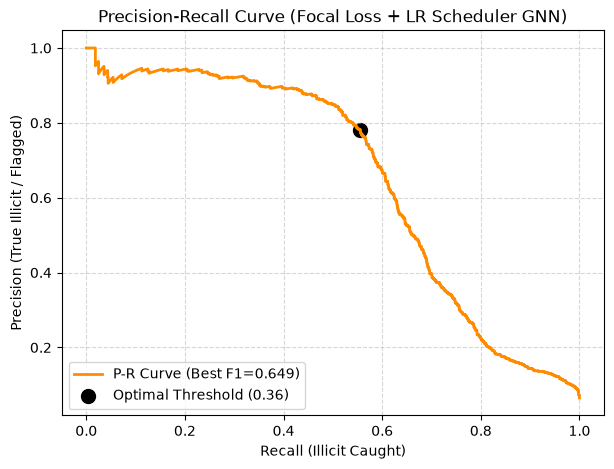

In [56]:
# 1. Compute the Precision-Recall curve values across all thresholds
precision_vals, recall_vals, thresholds = precision_recall_curve(final_targets, final_probs, pos_label=1)

# 2. Calculate the F1-score vector
# Small epsilon (1e-8) prevents division by zero if precision + recall is 0
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-8)

# 3. Find where the F1-score peaks
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
best_f1 = f1_scores[best_idx]
best_precision = precision_vals[best_idx]
best_recall = recall_vals[best_idx]

print("================ FINAL PERFORMANCE METRICS ================")
print(f"Optimal Classification Threshold: {best_threshold:.4f}")
print(f"Maximized Illicit Precision:      {best_precision:.4f}")
print(f"Maximized Illicit Recall:         {best_recall:.4f}")
print(f"Optimized Illicit F1-Score:       {best_f1:.4f}")
print("===========================================================\n")

# 4. Plot the Precision-Recall curve
plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, color='darkorange', lw=2, label=f'P-R Curve (Best F1={best_f1:.3f})')
plt.scatter(best_recall, best_precision, color='black', marker='o', s=100, label=f'Optimal Threshold ({best_threshold:.2f})')
plt.xlabel('Recall (Illicit Caught)')
plt.ylabel('Precision (True Illicit / Flagged)')
plt.title('Precision-Recall Curve (Focal Loss + LR Scheduler GNN)')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [57]:
# Save embeddings
# The layer 1 pass for whole graph:

model.eval()
global_ids=torch.arange(graph.num_nodes)
embedding_loader=NeighborLoader(graph,num_neighbors=[-1],batch_size=batch_size,
                                input_nodes=global_ids,shuffle=False)
layer1_embeddings=torch.zeros((graph.num_nodes,64))
start=0                                                                 # To manually get the indices of current nodes in batch and store in layer 1 matrix coz shuffle is false
                                                                            # So, it will go in order 0->203...
print('Starting Layer 1 pass for all nodes...')
with torch.no_grad():
    for batch in embedding_loader:
        x_1=model.sage(batch.x,batch.edge_index)
        x_1=F.relu(x_1)
        num_targets=batch.batch_size                            # Why? : because a batch may have less than 1024 target nodes, we dont know how many.
        target_embeddings=x_1[:num_targets]
        
        global_node_ids = global_ids[start : start+num_targets]
        
        layer1_embeddings[global_node_ids] = target_embeddings
        start += num_targets

print("Layer 1 embeddings generated.")

Starting Layer 1 pass for all nodes...
Layer 1 embeddings generated.


In [58]:
# Layer 2 embeddings : (64 * 4), the 4 attention heads
embedding_loader2=NeighborLoader(graph,num_neighbors=[-1],batch_size=batch_size,
                                input_nodes=global_ids,shuffle=False)
layer2_embeddings=torch.zeros((graph.num_nodes,256))
start=0

print('Starting Layer 2 pass for all nodes...')
with torch.no_grad():
    for batch in embedding_loader2:

        num_targets=batch.batch_size
        layer1_batch=layer1_embeddings[batch.n_id].to(batch.x)

        x_2=model.gat(layer1_batch,batch.edge_index)
        x_2=F.relu(x_2)
                                   
        target_embeddings=x_2[:num_targets]
        
        global_node_ids = global_ids[start : start+num_targets]
        
        layer2_embeddings[global_node_ids] = target_embeddings
        start += num_targets

print("Layer 2 embeddings generated.")

Starting Layer 2 pass for all nodes...
Layer 2 embeddings generated.


In [59]:
print(layer2_embeddings.shape)
original_features=graph.x
final_vectors=torch.concat((layer2_embeddings,original_features),dim=1).numpy()
print(final_vectors.shape)

torch.Size([203769, 256])
(203769, 421)


In [60]:
df=pd.DataFrame(final_vectors)
df.to_parquet('/Users/rageshwer/Goal ML/Projects/AML - GNN/data/processed/final_vectors.parquet')